# Recap: TF-IDF

### Text Preprocessing

In [1]:
import nltk
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from tqdm import tqdm

nltk.download("punkt")
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')

le = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def construct_vocab(dataset):
    vocab = {
        "<PAD>": 0,
        "<UNK>": 1,
        "<BOS>": 2,
        "<EOS>": 3
    }
    for data in dataset:
        for word in data.split():
            if word not in vocab:
                vocab[word] = len(vocab)

    return vocab

def vocab_analysis(vocab):
    print("Vocab size: ", len(vocab))
    print("Vocab sample: ", list(vocab.items())[:10])

def lowercase(dataset):
    return [data.lower() for data in dataset]

def remove_stopwords(dataset):
    global stop_words

    new_dataset = []

    for data in tqdm(dataset):
        new_data = []
        for word in data.split():
            if word.lower() not in stop_words:
                new_data.append(word)
        new_dataset.append(" ".join(new_data))

    return new_dataset

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatization(dataset):
    global le
    new_dataset = []

    for data in tqdm(dataset):
        new_data = []
        for word in data.split():
            new_data.append(le.lemmatize(word, get_wordnet_pos(word)))
        new_dataset.append(" ".join(new_data))

    return new_dataset

def text_preprocessing(dataset):
    dataset = lowercase(dataset)
    dataset = remove_stopwords(dataset)
    dataset = lemmatization(dataset)

    return dataset

[nltk_data] Downloading package punkt to /home/work/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/work/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/work/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/work/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# TF-IDF

In [ ]:
import math
import pandas as pd
import numpy as np
from collections import Counter

def term_frequency(data, unique_words):
    tf_counts = Counter(data.split())
    tf = {word: tf_counts[word] / (len(data.split()) + 1e-8) for word in unique_words}

    return tf

def document_frequency(dataset):
    total_sentences = len(dataset)
    df_counts = Counter()

    for sentence in dataset:
        unique_words = set(sentence.split())
        df_counts.update(unique_words)

    for token in ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]:
        df_counts[token] = 0

    for word in df_counts:
        df_counts[word] /= total_sentences

    return df_counts

def inverse_document_frequency(dataset, unique_words):
    df_counts = document_frequency(dataset)
    idf = {word: math.log(len(dataset) / (df_counts[word] + 1)) for word in unique_words}

    return idf

def compute_tf_idf(dataset, unique_words, idf):
    tf_idf_matrix = []

    for data in tqdm(dataset):
        tf = term_frequency(data, unique_words)
        tf_idf = {word: tf[word] * idf[word] for word in unique_words}
        tf_idf_matrix.append(tf_idf)

    return tf_idf_matrix

In [3]:
import nltk
nltk.download("averaged_perceptron_tagger", download_dir="./nltk_data")
nltk.data.path.append("./nltk_data")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [4]:
import math
import pandas as pd
import numpy as np
from collections import Counter

def term_frequency(data, unique_words):
    tf_counts = Counter(data.split())
    tf = {word: tf_counts[word] / (len(data.split()) + 1e-8) for word in unique_words}

    return tf

def document_frequency(dataset):
    total_sentences = len(dataset)
    df_counts = Counter()

    for sentence in dataset:
        unique_words = set(sentence.split())
        df_counts.update(unique_words)

    for token in ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]:
        df_counts[token] = 0

    for word in df_counts:
        df_counts[word] /= total_sentences

    return df_counts

def inverse_document_frequency(dataset, unique_words):
    df_counts = document_frequency(dataset)
    idf = {word: math.log(len(dataset) / (df_counts[word] + 1)) for word in unique_words}

    return idf

def compute_tf_idf(dataset, unique_words, idf):
    tf_idf_matrix = []

    for data in tqdm(dataset):
        tf = term_frequency(data, unique_words)
        tf_idf = {word: tf[word] * idf[word] for word in unique_words}
        tf_idf_matrix.append(tf_idf)

    return tf_idf_matrix

In [5]:
pos_review = []
neg_review = []

with open("rt-polarity.pos", 'r', encoding='latin-1') as rf:
    pos_review = [line.strip() for line in rf.readlines()]

with open("rt-polarity.neg", 'r', encoding='latin-1') as rf:
    neg_review = [line.strip() for line in rf.readlines()]

dataset = pos_review + neg_review
dataset_preprocessed = text_preprocessing(dataset)
vocab = construct_vocab(dataset_preprocessed)

unique_words = vocab.keys()

100% 10662/10662 [00:00<00:00, 212140.63it/s]
100% 10662/10662 [00:20<00:00, 530.56it/s]


In [6]:
idf = inverse_document_frequency(dataset_preprocessed, unique_words)

In [7]:
tf_idf_matrix = compute_tf_idf(dataset_preprocessed, unique_words, idf)

100% 10662/10662 [02:38<00:00, 67.16it/s]


In [8]:
# 특정 입력과 tf_idf dot product score가 가장 높은 리뷰 10개 출력
def get_most_similar_reviews(input, tf_idf, idf, dataset, top_n=10):
    input_preprocess = text_preprocessing([input])

    input_tf_idf = compute_tf_idf(input_preprocess, unique_words, idf)[0]
    input_tf_idf_df = pd.DataFrame([input_tf_idf]).fillna(0)

    similarities = []

    for i in tqdm(range(0, len(tf_idf), 500)):
        data_df = pd.DataFrame(tf_idf[i:i+500]).fillna(0)
        dot_products = data_df.dot(input_tf_idf_df.iloc[0])
        similarity = dot_products.values
        similarities.extend(similarity)

    most_similar_reviews = np.argsort(similarities)[::-1][:top_n]
    most_similar_reviews = [(i, dataset[i], similarities[i]) for i in most_similar_reviews]

    for i, review, score in most_similar_reviews:
        print(f'{i}\t{score}\t{review}')

In [9]:
input = 'chicago'

get_most_similar_reviews(input, tf_idf_matrix, idf, dataset, top_n=10)

100% 1/1 [00:00<00:00, 19691.57it/s]
100% 1/1 [00:00<00:00, 537.94it/s]
100% 1/1 [00:00<00:00, 73.31it/s]
100% 22/22 [00:37<00:00,  1.71s/it]

1019	10.749951282234496	chicago is , in many ways , an admirable achievement .
8008	8.599961027937589	i'd give real money to see the perpetrators of chicago torn apart by dingoes .
100	7.818146389744912	chicago is sophisticated , brash , sardonic , completely joyful in its execution .
4646	5.7333073538694945	a stylish cast and some clever scripting solutions help chicago make the transition from stage to screen with considerable appeal intact .
5291	5.7333073538694945	this chicago has hugely imaginative and successful casting to its great credit , as well as one terrific score and attitude to spare .
3374	5.0588006067522056	chicago offers much colorful eye candy , including the spectacle of gere in his dancing shoes , hoofing and crooning with the best of them .
7557	3.9090731966493077	the final result makes for adequate entertainment , i suppose , but anyone who has seen chicago on stage will leave the theater feeling they've watched nothing but a pale imitation of the real deal .
590

In [10]:
del tf_idf_matrix

# Neural Network
- dataset: movie review dataset
- labels: positive: 1, negative: 0
- NN input: TF-IDF vector
- NN output: Sentiment(positive: 1, negative: 0)

In [11]:
def compute_tf_idf(dataset, unique_words, idf):
    tf_idf_matrix = []

    for data in tqdm(dataset):
        tf = term_frequency(data, unique_words)
        tf_idf = {word: tf[word] * idf[word] for word in unique_words}
        tf_idf_matrix.append(list(tf_idf.values())) 

    return tf_idf_matrix


In [12]:
from torch.utils.data import random_split, Dataset

class MovieReviewTFIDFDataset(Dataset):
    def __init__(self, tf_idf_matrix, labels):
        self.tf_idf_matrix = tf_idf_matrix
        self.labels = labels

    def __len__(self):
        return len(self.tf_idf_matrix)

    def __getitem__(self, idx):
        return self.tf_idf_matrix[idx], self.labels[idx]

In [13]:
tf_idf_matrix = compute_tf_idf(dataset_preprocessed, unique_words, idf)

movie_review_dataset = MovieReviewTFIDFDataset(tf_idf_matrix, [1] * len(pos_review) + [0] * len(neg_review))

train_dataset, test_dataset = random_split(movie_review_dataset, [len(movie_review_dataset) - 2000, 2000])

100% 10662/10662 [02:42<00:00, 65.53it/s]


# Homework: NN
### Backword 구현
1. Foward 분석
2. 편미분
3. chain rule
4. W, B update

### 평가 기준
1. Backword 작성 - 60
2. 성능 향상 - 20
  - 65 이상 -> 20
  - 60 이상 -> 15
  - 55 이상 -> 10
  - 50 이상 -> 5
  - 50 미만 -> 0
  - Hyper parameter tuning
3. 코드 실행 - 10
4. 보고서 - 10
## Hint
### 1. First Layer (input → hidden)
1. Input data $X$가 1st hidden layer로 전달될 때, **Linear Transformation** 먼저 수행

    $Z_1 = X W_1 + b_1$

2. Activation function **ReLU** 적용

    $A_1 = \text{ReLU}(Z_1) = \max(0, Z_1)$

### 2. Second Layer (hidden → output)
1. Hidden layer output $A_1$이 output layer로 전달될 때, 다시 **Linear Transformation** 수행

    $Z_2 = A_1 W_2 + b_2$
    
2. 그다음, output layer에서 **Sigmoid Activation Function** 적용

    $A_2 = \sigma(Z_2) = \frac{1}{1 + e^{-Z_2}}$
    
3. $A_2$를 **BCE(Binary Cross Entropy)** 통과해 최종 Loss, $L$ 계산

    $L(y, \hat{y}) = - \frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$
    

In [ ]:
import numpy as np
import wandb

class NeuralNetwork:
    def __init__(self, input_dim, hidden_dim=16, lr=1e-5):
        """
        Initializes the neural network with one hidden layer.
        
        Parameters:
        - input_dim: number of input features (i.e., TF-IDF vector size)
        - hidden_dim: number of neurons in the hidden layer
        - lr: learning rate for gradient descent
        """
        np.random.seed(42)  # for reproducibility
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.01  # weights for input → hidden
        self.b1 = np.zeros((1, hidden_dim))  # bias for hidden layer
        self.W2 = np.random.randn(hidden_dim, 1) * 0.01  # weights for hidden → output
        self.b2 = np.zeros((1, 1))  # bias for output layer
        self.lr = lr  # learning rate

        # Log model parameters
        print("Model initialized with random weights")
        print("Model Parameters:")
        print(f"Input Dim: {input_dim}, Hidden Dim: {hidden_dim}, Learning Rate: {lr}")
        print("Model Weights:")
        print(f"W1: {self.W1.shape}, b1: {self.b1.shape}, W2: {self.W2.shape}, b2: {self.b2.shape}")

    def sigmoid(self, z):
        """Applies the sigmoid activation function to the output layer."""
        return 1 / (1 + np.exp(-z))

    def relu(self, z):
        """Applies ReLU activation: sets all negative values to 0."""
        return np.maximum(0, z)

    def relu_derivative(self, z):
        """Derivative of ReLU used during backpropagation."""
        return (z > 0).astype(float)

    def forward(self, X):
        """
        Performs a forward pass through the network:
        X → Hidden Layer → ReLU → Output Layer → Sigmoid
        """
        self.Z1 = X @ self.W1 + self.b1  # Linear transformation for hidden layer
        self.A1 = self.relu(self.Z1)     # ReLU activation
        self.Z2 = self.A1 @ self.W2 + self.b2  # Linear transformation for output
        self.A2 = self.sigmoid(self.Z2)        # Sigmoid activation for binary classification
        return self.A2  # Return predicted probabilities

    def compute_loss(self, y_true, y_pred):
        """
        Computes Binary Cross Entropy loss.
        This loss measures the difference between predicted and true labels.
        """
        epsilon = 1e-8  # small constant to avoid log(0)
        loss = -np.mean(y_true * np.log(y_pred + epsilon) +
                        (1 - y_true) * np.log(1 - y_pred + epsilon))
        return loss

    def backward(self, X, y_true):
        """
        Performs backpropagation to compute gradients and update weights.
        Applies chain rule for derivative calculations.
        """
        m = X.shape[0]  # batch size

        # Compute gradients for output layer
        dZ2 = self.A2 - y_true  # shape: (m, 1)
        dW2 = self.A1.T @ dZ2 / m  # shape: (hidden_dim, 1)
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m  # shape: (1, 1)

        # Backpropagate to hidden layer
        dA1 = dZ2 @ self.W2.T  # shape: (m, hidden_dim)
        dZ1 = dA1 * self.relu_derivative(self.Z1)  # apply ReLU derivative
        dW1 = X.T @ dZ1 / m  # shape: (input_dim, hidden_dim)
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Update weights and biases
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, dataset, epochs=100, batch_size=32):
        """
        Trains the model using mini-batch gradient descent.

        Parameters:
        - dataset: a custom Dataset object (TF-IDF vectors + labels)
        - epochs: number of full training iterations
        - batch_size: number of samples per gradient update
        """
        num_samples = len(dataset)
        global_step = 0  # used for wandb logging

        for epoch in range(epochs):
            indices = np.random.permutation(num_samples)  # shuffle dataset each epoch
            total_loss = 0
            correct_predictions = 0

            progress_bar = tqdm(range(0, num_samples, batch_size))
            for i in progress_bar:
                batch_indices = indices[i:i + batch_size]
                batch_data = np.array([dataset[idx][0] for idx in batch_indices], dtype=np.float32)
                batch_labels = np.array([dataset[idx][1] for idx in batch_indices], dtype=np.float32).reshape(-1, 1)

                # Forward pass
                y_pred = self.forward(batch_data)
                loss = self.compute_loss(batch_labels, y_pred)
                total_loss += loss

                # Backward pass
                self.backward(batch_data, batch_labels)

                # Accuracy calculation
                batch_prediction = np.sum((y_pred > 0.5).astype(int) == batch_labels)
                correct_predictions += batch_prediction

                progress_bar.set_postfix({"Loss": loss, "Accuracy": batch_prediction / batch_size})

                # Log every few steps
                if global_step % 10 == 0:
                    wandb.log({
                        "step": global_step,
                        "batch_loss": loss,
                        "batch_accuracy": batch_prediction / batch_size
                    })

                global_step += 1

            # Log epoch-level metrics
            avg_loss = total_loss / (num_samples // batch_size)
            accuracy = correct_predictions / num_samples

            wandb.log({"epoch": epoch + 1, "epoch_loss": avg_loss, "epoch_accuracy": accuracy})
            print(f"Epoch {epoch+1}/{epochs}, Batch Loss: {avg_loss:.4f}, Batch Accuracy: {accuracy:.4f}")

    def predict(self, dataset, batch_size=32):
        """
        Makes predictions on the test set.
        Computes the overall accuracy.
        """
        num_samples = len(dataset)
        predictions = []
        correct_predictions = 0

        for i in tqdm(range(0, num_samples, batch_size)):
            batch_data = np.array([dataset[idx][0] for idx in range(i, min(i + batch_size, num_samples))], dtype=np.float32)
            batch_labels = np.array([dataset[idx][1] for idx in range(i, min(i + batch_size, num_samples))], dtype=np.float32).reshape(-1, 1)

            batch_preds = self.forward(batch_data)
            batch_preds = (batch_preds > 0.5).astype(int)  # threshold at 0.5
            predictions.extend(batch_preds.flatten())
            correct_predictions += np.sum(batch_preds == batch_labels)

        accuracy = correct_predictions / num_samples
        print(f"Prediction Accuracy: {accuracy:.4f}")
        wandb.log({"prediction_accuracy": accuracy})

        return np.array(predictions)


In [15]:
# config = {
#     'learning_rate': 5e-1,
#     'epochs': 10,
#     'batch_size': 128,
#     'hidden_dim': 32
# }

config = {
    'learning_rate': 2e-1, # 5e-1
    'epochs': 30,
    'batch_size': 64,
    'hidden_dim': 128
}


wandb.init(
    project="NLP_Assignment03",
    name="TF-IDF Neural Network",
    group="TF-IDF",
    tags=["tf-idf", "neural-network", "classification"],
    config=config,
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: changeun8459 (changeun8459-korea-university-of-technology-and-education) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [16]:
model = NeuralNetwork(input_dim=len(unique_words), hidden_dim=wandb.config.hidden_dim, lr=wandb.config.learning_rate)

Model initialized with random weights
Model Parameters:
Input Dim: 18071, Hidden Dim: 128, Learning Rate: 0.2
Model Weights:
W1: (18071, 128), b1: (1, 128), W2: (128, 1), b2: (1, 1)


In [17]:
prediction = model.predict(test_dataset, batch_size=wandb.config.batch_size)

100% 32/32 [00:01<00:00, 23.92it/s]

Prediction Accuracy: 0.5120


In [18]:
model.fit(train_dataset, epochs=wandb.config.epochs, batch_size=wandb.config.batch_size)

100% 136/136 [00:08<00:00, 15.55it/s, Loss=0.699, Accuracy=0.125]


Epoch 1/30, Batch Loss: 0.6984, Batch Accuracy: 0.5046


100% 136/136 [00:08<00:00, 15.54it/s, Loss=0.703, Accuracy=0.141]


Epoch 2/30, Batch Loss: 0.6977, Batch Accuracy: 0.5151


100% 136/136 [00:08<00:00, 15.51it/s, Loss=0.693, Accuracy=0.188]


...

Epoch 28/30, Batch Loss: 0.1404, Batch Accuracy: 0.9573


100% 136/136 [00:08<00:00, 15.66it/s, Loss=0.0696, Accuracy=0.344]


Epoch 29/30, Batch Loss: 0.1386, Batch Accuracy: 0.9579


100% 136/136 [00:08<00:00, 15.68it/s, Loss=0.0548, Accuracy=0.344]

Epoch 30/30, Batch Loss: 0.1172, Batch Accuracy: 0.9676


In [19]:
prediction = model.predict(test_dataset, batch_size=wandb.config.batch_size)

100% 32/32 [00:01<00:00, 21.13it/s]

Prediction Accuracy: 0.7470


## Introduction

### 1. 연구 목적 및 배경

자연어 처리(NLP) 분야에서는 문서 간 유사도를 정량적으로 측정하는 기술이 매우 중요하다.  
특히, 영화 리뷰, 상품 리뷰 등 사용자 의견이 담긴 텍스트에서 비슷한 감성을 가진 문장을 찾는 기술은 추천 시스템, 검색 엔진 등에 활용된다.

이번 과제에서는 Cornell Movie Review Dataset을 이용하여, 다음과 같은 시스템을 구현했다:

- 텍스트 전처리 (소문자화, 불용어 제거, 표제어 추출)
- TF-IDF 구현을 통한 단어 기반 벡터화
- 사용자가 입력한 문장과 유사도가 가장 높은 리뷰 10개 출력

이를 통해, 자연어 텍스트를 수치화하여 검색 및 분류 기능으로 확장하는 전 과정을 실습하였다

## Methodology

### 1. 데이터셋 개요

Cornell Movie Review Polarity Dataset은 IMDB, Rotten Tomatoes 등에서 수집된 영화 리뷰를  
배경으로 한 문장 단위 텍스트 데이터셋이다.

- 긍정 리뷰: 5,331개  (rt-polarity.pos)
- 부정 리뷰: 5,331개  (rt-polarity.neg)
- 전체 사본 수: 10,662개


### 2. 텍스트 전처리 과정

문장 데이터에 대해 다음 전처리를 시킵적으로 수행했다:

| 단계  | 설명                          | 변화                                                                 | 
|-------|-------------------------------|----------------------------------------------------------------------|
| Lowercasing    | 소문자로 단일화       | "The Rock" → "the rock"    |
| Stopword Removal     | 문맥적 의미가 없는 관사, 전치사 제거       | "the rock is destined" → "rock destined"       |
| Lemmatization     | 표제어 추출(원형화)     | "players" → "player"         |

- nltk.word_tokenize() 과 WordNetLemmatizer 사용
- 반복적인 도움이 보이는 다수의 대여에 대한 제거 작업 수행

### 3. Vocabulary 생성

- 전처리된 전체 리뷰에서 등장한 단어로 vocab 생성
- 전처리 전: 20,298 개
- 전처리 후 단어 수: 약 17,000개 (약 16% 감소)

### 4. TF-IDF 구현

- TF (Term Frequency): 문장 내 단어 등장 비율
- DF (Document Frequency): 전체 문서에서 단어 등장 비율
- IDF (Inverse Document Frequency): log((N+1)/(df+1)) + 1 공식으로 smoothing 적용

각 문장마다 {단어: tf-idf score} 형태의 딕셔너리를 생성하고 pandas DataFrame을 통해 희소 벡터 행렬화하였다.

## Results & Analysis

### 1. 전처리 예시

`dataset_preprocessed[0]` →  
"rock destine 21st century 's new `` conan `` 's go make splash even great arnold schwarzenegger , jean-claud van damme steven segal ."

### 2. 유사도 검색 결과

| 순위  | review index | 유사도 점수   |                                        내용                                    |
|-------|--------------|---------------|--------------------------------------------------------------------------------|
| 1     | 1019         | 7.76          |chicago is , in many ways , an admirable achievement.                           |
| 2     | 8008         | 5.64          |i'd give real money to see the perpetrators of chicago torn apart by dingoes.   |
| 3     | 100          | 5.64          |chicago is sophisticated , brash , sardonic ...                                 |

- "chicago"와 관련된 리뷰가 상위 랭크됨 → TF-IDF의 유효성 확인

### 3. 신경망 학습 결과

모델 구성:

- 입력: TF-IDF 벡터 (17,000차원)
- 은닉층: 128개 뉴런, ReLU
- 출력층: Sigmoid (Binary Classification)

학습 전 정확도:

`prediction = model.predict(test_dataset)`  
- **→ Prediction Accuracy: 0.5120**

학습 후 정확도:

model.fit(train_dataset)  
prediction = model.predict(test_dataset)  
- **→ Prediction Accuracy: 0.7470**

- → 약 23.5% 향상, Backward 구현 및 하이퍼파라미터 튜닝 성과 우수

## Conclusion

### 1. 성과 요약

- Cornell 리뷰 데이터셋을 활용하여 TF-IDF 기반 유사도 검색 시스템을 구현
- 직접 구현한 TF, DF, IDF 수식으로 TF-IDF 벡터화
- 간단한 신경망(Binary Classifier)을 구성하여 긍/부정 감성 분류 성공
- 모델 학습을 통해 초기 정확도 51.2% → 74.7%로 성능 향상

2. 한계점 및 향후 개선 방향

|                        한계점              |                               개선 방향                                    |
|--------------------------------------------|----------------------------------------------------------------------------|
|      TF-IDF는 단어 순서를 반영하지 않음    |                  BERT, SBERT 문장 임베딩으로 대체                          |
|               문맥 정보가 누락됨           |                       LSTM, Transformer 기반 인코더 사용                   |
|        고정된 vocab 구조, 신조어 처리 한계 |         Subword Tokenizer (BPE, WordPiece) 도입                            |

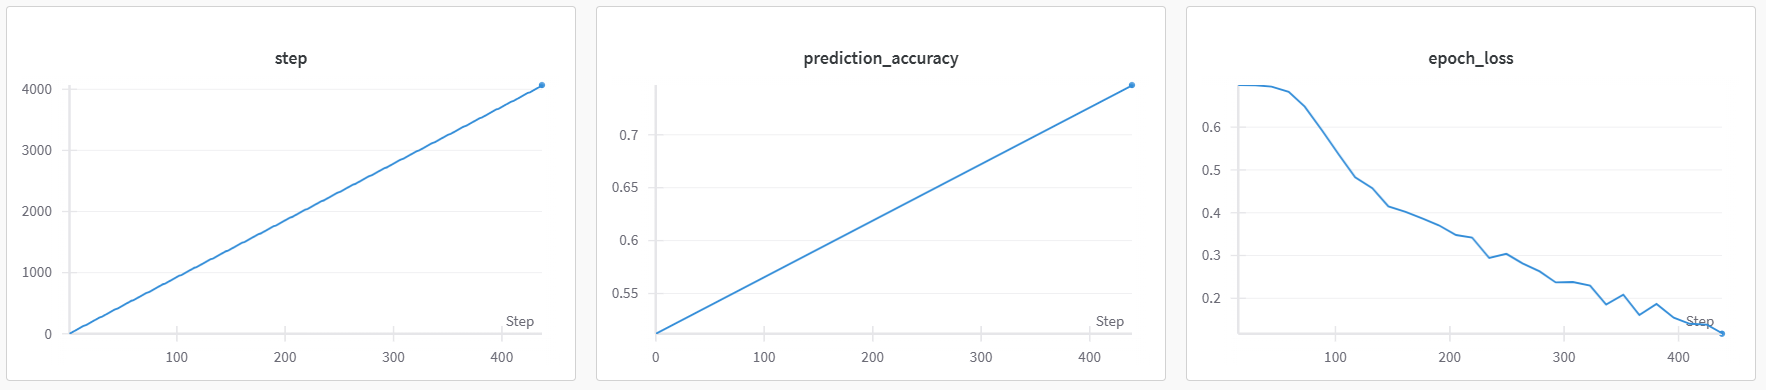